# AutoEncoder on MNIST


In [1]:
# 기본 패키지 임포트
import os, random
from pathlib import Path


# torch 패키지 임포트
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# 데이터 처리 패키지 임포트
from torchvision import datasets, transforms, utils

# 시각화 패키지 임포트
import matplotlib.pyplot as plt
import numpy as np


# Hyperparameter 설정


In [2]:
CFG = {
    "epochs": 5,
    "batch_size": 128,
    "lr": 1e-3,
    "latent_dim": 128,    # 잠재공간 차원
    "image_size": 28,     # MNIST 원본 크기
    "num_workers": 2,
    "seed": 42,
    "out_dir": "./samples_ae",
    "data_root": "./data",
}

# 랜덤 시드 설정
random.seed(CFG["seed"])
torch.manual_seed(CFG["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 결과 저장 경로 생성
Path(CFG["out_dir"]).mkdir(parents=True, exist_ok=True)
Path(CFG["data_root"]).mkdir(parents=True, exist_ok=True)


Using device: cpu


# 데이터셋: MNIST 로드 및 전처리


In [3]:
# 데이터 전처리 정의
transform = transforms.Compose([
    transforms.Resize(CFG["image_size"]),
    transforms.ToTensor(),
    # AutoEncoder는 [0,1] 범위 사용
])

# 데이터셋 로드
dataset = datasets.MNIST(
    root=CFG["data_root"], train=True, download=True, transform=transform
)

# 데이터 로더 생성
dloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=CFG["num_workers"],
    drop_last=True
)

print(f"Dataset size: {len(dataset)}")
print(f"Number of batches: {len(dloader)}")


100%|██████████| 9.91M/9.91M [00:00<00:00, 38.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.05MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.95MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.36MB/s]

Dataset size: 60000
Number of batches: 468


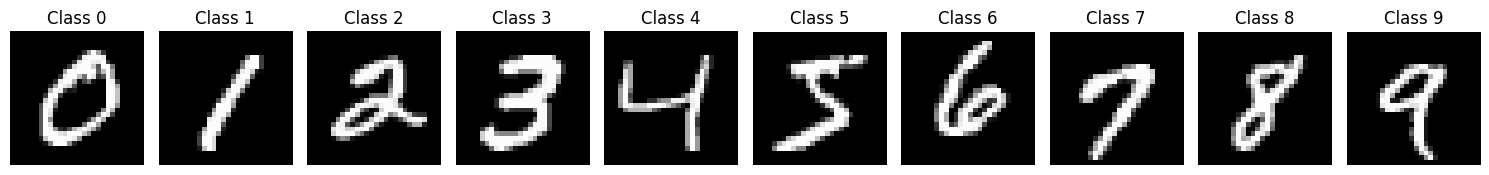

In [4]:
# MNIST 각 클래스별로 첫 번째 이미지를 모아 시각화
class_images = [None] * 10
class_found = [False] * 10

for img, label in dataset:
    if not class_found[label]:
        class_images[label] = img
        class_found[label] = True
    if all(class_found):
        break

plt.figure(figsize=(15, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(class_images[i].squeeze(), cmap='gray')
    plt.title(f"Class {i}")
    plt.axis('off')
plt.tight_layout()
plt.show()


# 모델 정의 (Convolutional AutoEncoder)

## AutoEncoder 모델 정의

AutoEncoder의 특징:
- 이미지를 저차원 잠재벡터로 압축 (Encoder)
- 잠재벡터를 다시 이미지로 복원 (Decoder)
- 재구성(Reconstruction)에 특화
- 잠재공간이 정규화되지 않음 → 랜덤 샘플링 불가능


In [5]:
# Encoder: 이미지 -> 잠재벡터
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        # MNIST: 1x28x28
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),  # 14x14
            nn.ReLU(True),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), # 7x7
            nn.ReLU(True),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), # 4x4 (실제로는 3.5x3.5이지만 4x4로 됨)
            nn.ReLU(True),
        )
        # 128 * 4 * 4 = 2048
        self.fc = nn.Linear(128 * 4 * 4, latent_dim)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)  # flatten
        z = self.fc(x)
        return z


In [6]:
# Decoder: 잠재벡터 -> 이미지
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 128 * 4 * 4)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),  # 8x8
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),   # 16x16
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 1, 4, stride=2, padding=3),    # 28x28
            nn.Sigmoid(),  # [0, 1] 범위로 출력
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(x.size(0), 128, 4, 4)
        x = self.deconv(x)
        return x


In [7]:
# AutoEncoder: Encoder + Decoder
class AutoEncoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

# 모델 생성
model = AutoEncoder(CFG["latent_dim"]).to(device)
print(f"AutoEncoder 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")


AutoEncoder 파라미터 수: 783,585


# 최적화 정의


In [8]:
# Reconstruction Loss (MSE 또는 BCE)
criterion = nn.MSELoss()  # 또는 nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=CFG["lr"])


# 시각화 및 샘플링을 위한 유틸 함수 정의


In [9]:
# 텐서 이미지 시각화 함수
def show_tensor_images(tensor, nrow=8, title="Images"):
    grid = utils.make_grid(tensor, nrow=nrow, normalize=False)
    plt.figure(figsize=(10, 10))
    plt.axis('off')
    plt.title(title)
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap='gray')
    plt.show()

# 재구성 결과 비교 함수
@torch.no_grad()
def show_reconstruction(num_images=16):
    model.eval()
    # 랜덤하게 이미지 선택
    indices = torch.randint(0, len(dataset), (num_images,))
    images = torch.stack([dataset[i][0] for i in indices]).to(device)

    # 재구성
    recon = model(images)

    # 원본과 재구성 이미지를 번갈아 보여주기
    comparison = torch.zeros(num_images * 2, 1, CFG["image_size"], CFG["image_size"])
    for i in range(num_images):
        comparison[i*2] = images[i].cpu()
        comparison[i*2 + 1] = recon[i].cpu()

    show_tensor_images(comparison, nrow=8, title="원본 vs 재구성 (교대)")
    model.train()

# 잠재공간에서 랜덤 샘플링하여 새로운 이미지 생성
@torch.no_grad()
def generate_random_samples(num_samples=64):
    model.eval()
    # 잠재공간에서 랜덤 샘플링
    z = torch.randn(num_samples, CFG["latent_dim"], device=device)
    samples = model.decode(z)
    show_tensor_images(samples.cpu(), nrow=8, title="랜덤 생성 이미지")
    model.train()
    return samples


# 모델 학습


[1/20] step 0 | loss=0.2133
[1/20] step 100 | loss=0.0595
[1/20] step 200 | loss=0.0256
[1/20] step 300 | loss=0.0157
[1/20] step 400 | loss=0.0105
Epoch 1 완료 | 평균 Loss: 0.0342


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/us

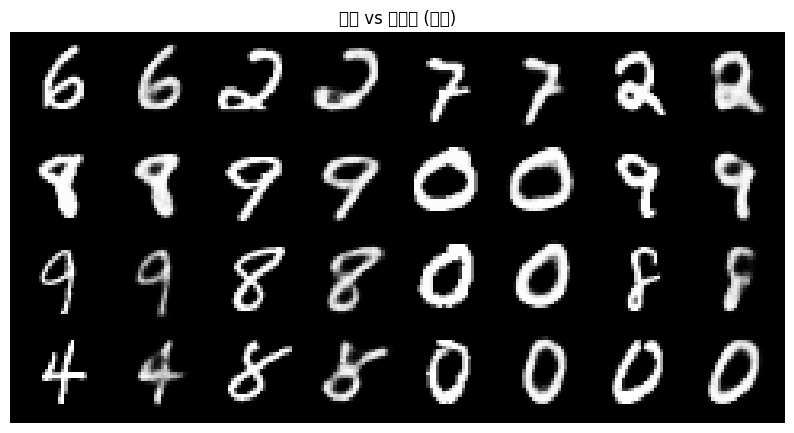

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47004 (\N{HANGUL SYLLABLE RAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45924 (\N{HANGUL SYLLABLE DEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

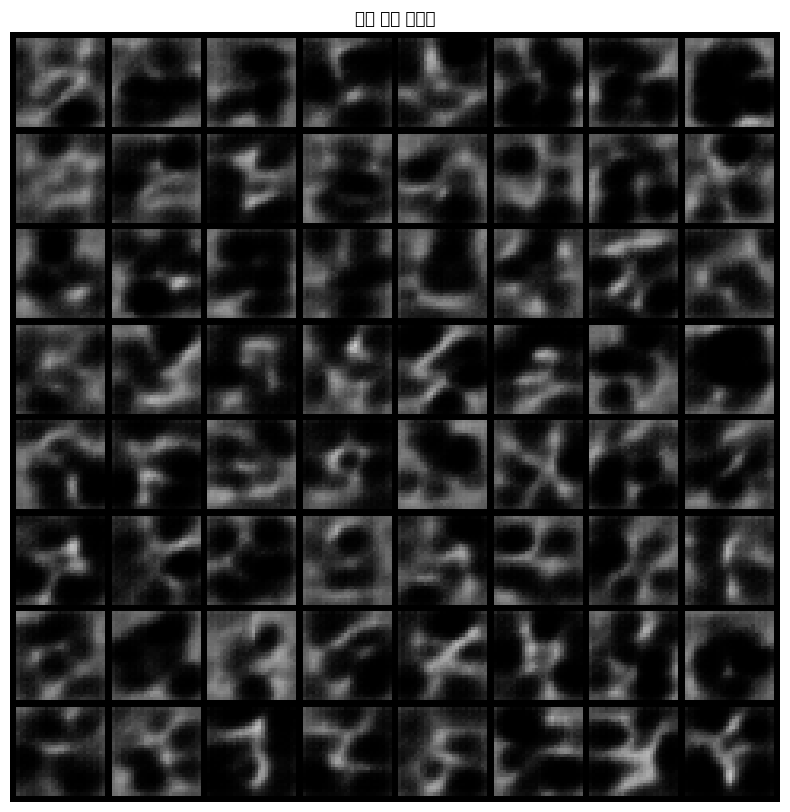

Saved: ./samples_ae/epoch_001.png
[2/20] step 500 | loss=0.0093
[2/20] step 600 | loss=0.0076
[2/20] step 700 | loss=0.0068
[2/20] step 800 | loss=0.0062
[2/20] step 900 | loss=0.0049
Epoch 2 완료 | 평균 Loss: 0.0068
[3/20] step 1000 | loss=0.0054
[3/20] step 1100 | loss=0.0051
[3/20] step 1200 | loss=0.0045
[3/20] step 1300 | loss=0.0037
[3/20] step 1400 | loss=0.0040
Epoch 3 완료 | 평균 Loss: 0.0045
[4/20] step 1500 | loss=0.0037
[4/20] step 1600 | loss=0.0039
[4/20] step 1700 | loss=0.0036
[4/20] step 1800 | loss=0.0030
Epoch 4 완료 | 평균 Loss: 0.0036
[5/20] step 1900 | loss=0.0034
[5/20] step 2000 | loss=0.0030
[5/20] step 2100 | loss=0.0031
[5/20] step 2200 | loss=0.0030
[5/20] step 2300 | loss=0.0026
Epoch 5 완료 | 평균 Loss: 0.0030


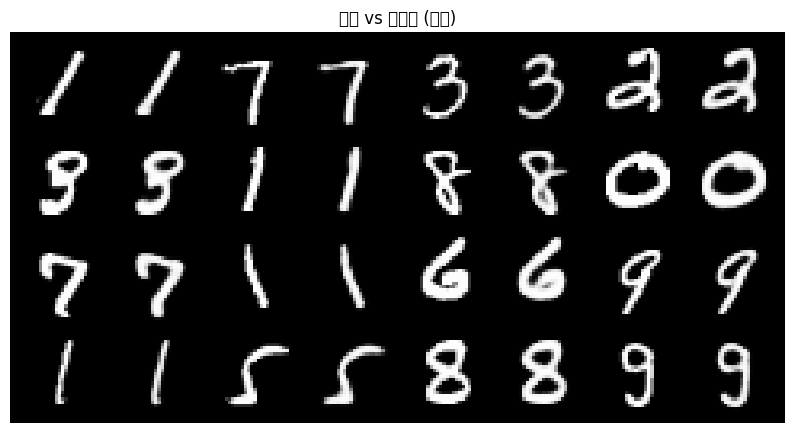

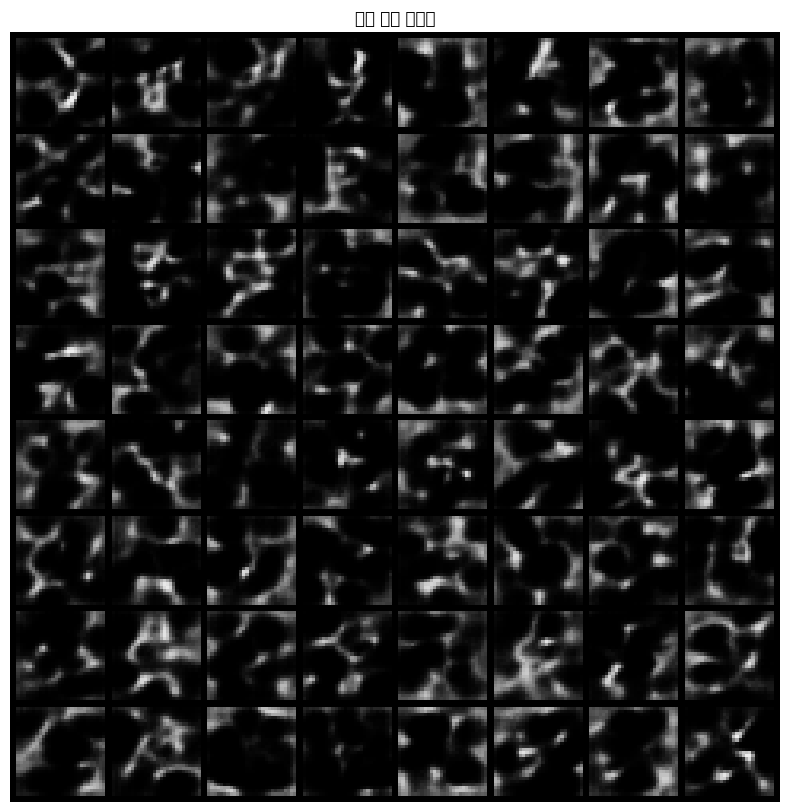

Saved: ./samples_ae/epoch_005.png
[6/20] step 2400 | loss=0.0025
[6/20] step 2500 | loss=0.0025
[6/20] step 2600 | loss=0.0026
[6/20] step 2700 | loss=0.0027
[6/20] step 2800 | loss=0.0026
Epoch 6 완료 | 평균 Loss: 0.0027
[7/20] step 2900 | loss=0.0023
[7/20] step 3000 | loss=0.0025
[7/20] step 3100 | loss=0.0028
[7/20] step 3200 | loss=0.0024
Epoch 7 완료 | 평균 Loss: 0.0024
[8/20] step 3300 | loss=0.0023
[8/20] step 3400 | loss=0.0023
[8/20] step 3500 | loss=0.0022
[8/20] step 3600 | loss=0.0022
[8/20] step 3700 | loss=0.0022
Epoch 8 완료 | 평균 Loss: 0.0022
[9/20] step 3800 | loss=0.0021
[9/20] step 3900 | loss=0.0021
[9/20] step 4000 | loss=0.0019
[9/20] step 4100 | loss=0.0020
[9/20] step 4200 | loss=0.0018
Epoch 9 완료 | 평균 Loss: 0.0021
[10/20] step 4300 | loss=0.0020
[10/20] step 4400 | loss=0.0019
[10/20] step 4500 | loss=0.0020
[10/20] step 4600 | loss=0.0019
Epoch 10 완료 | 평균 Loss: 0.0019


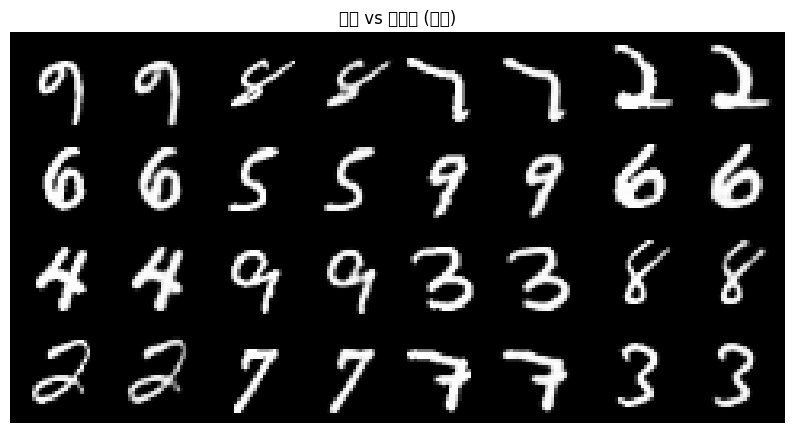

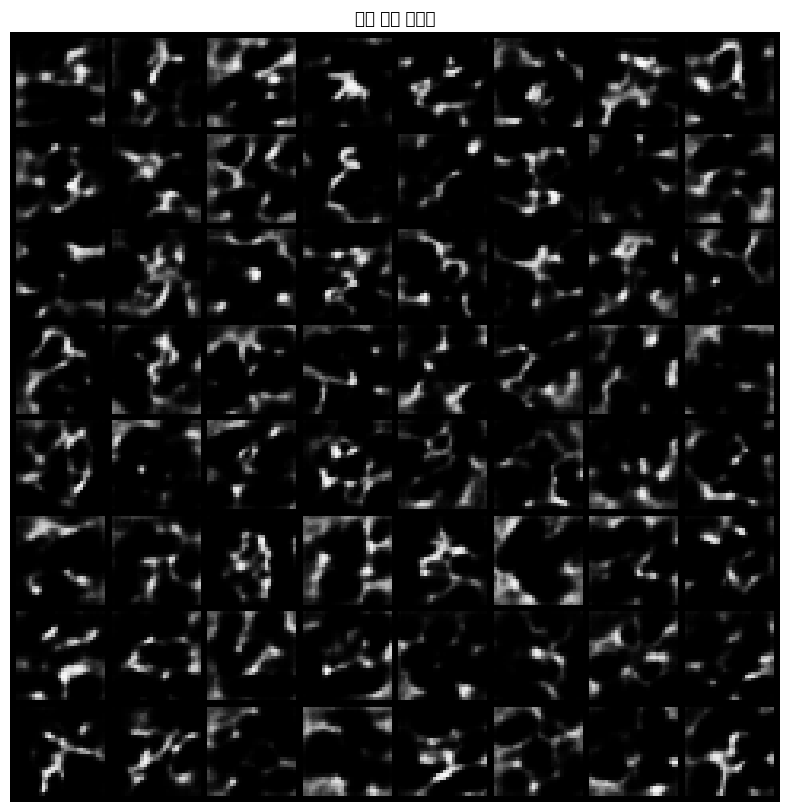

Saved: ./samples_ae/epoch_010.png
[11/20] step 4700 | loss=0.0018
[11/20] step 4800 | loss=0.0019
[11/20] step 4900 | loss=0.0017
[11/20] step 5000 | loss=0.0019
[11/20] step 5100 | loss=0.0017
Epoch 11 완료 | 평균 Loss: 0.0018
[12/20] step 5200 | loss=0.0018
[12/20] step 5300 | loss=0.0020
[12/20] step 5400 | loss=0.0017
[12/20] step 5500 | loss=0.0017
[12/20] step 5600 | loss=0.0017
Epoch 12 완료 | 평균 Loss: 0.0017
[13/20] step 5700 | loss=0.0017
[13/20] step 5800 | loss=0.0017
[13/20] step 5900 | loss=0.0016
[13/20] step 6000 | loss=0.0015
Epoch 13 완료 | 평균 Loss: 0.0016
[14/20] step 6100 | loss=0.0017
[14/20] step 6200 | loss=0.0016
[14/20] step 6300 | loss=0.0015
[14/20] step 6400 | loss=0.0016
[14/20] step 6500 | loss=0.0015
Epoch 14 완료 | 평균 Loss: 0.0016
[15/20] step 6600 | loss=0.0016
[15/20] step 6700 | loss=0.0015
[15/20] step 6800 | loss=0.0015
[15/20] step 6900 | loss=0.0014
[15/20] step 7000 | loss=0.0015
Epoch 15 완료 | 평균 Loss: 0.0015


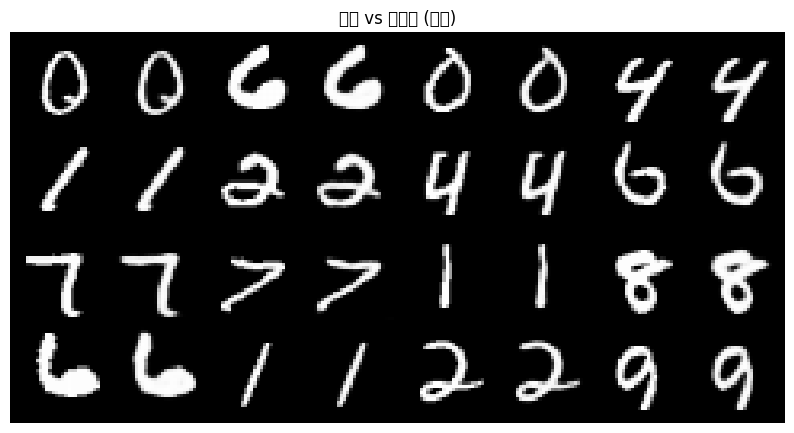

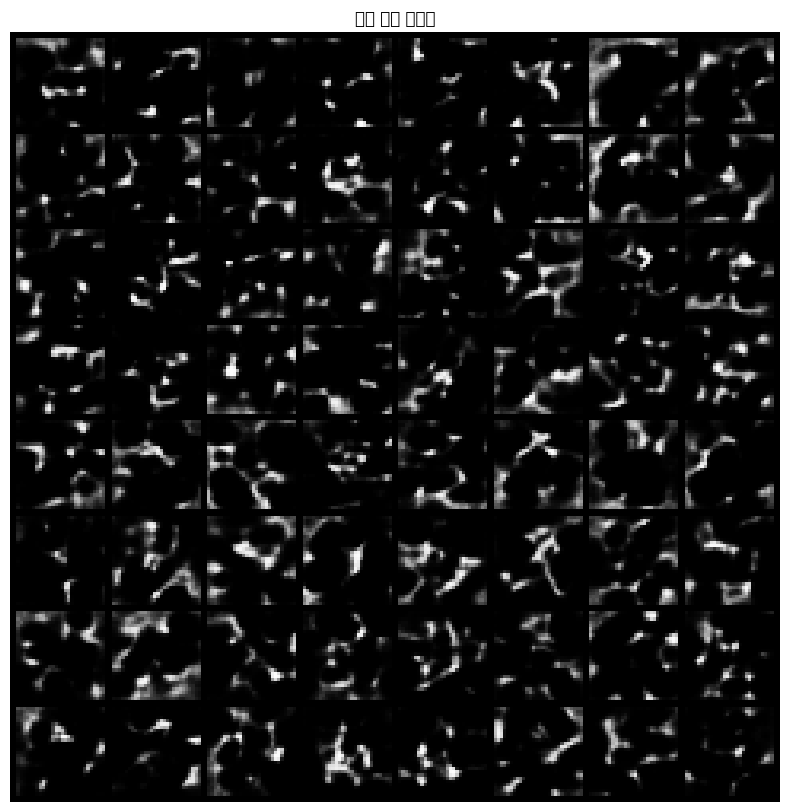

Saved: ./samples_ae/epoch_015.png
[16/20] step 7100 | loss=0.0014
[16/20] step 7200 | loss=0.0014
[16/20] step 7300 | loss=0.0014
[16/20] step 7400 | loss=0.0016
Epoch 16 완료 | 평균 Loss: 0.0014
[17/20] step 7500 | loss=0.0014
[17/20] step 7600 | loss=0.0013
[17/20] step 7700 | loss=0.0013
[17/20] step 7800 | loss=0.0014
[17/20] step 7900 | loss=0.0014
Epoch 17 완료 | 평균 Loss: 0.0014
[18/20] step 8000 | loss=0.0013
[18/20] step 8100 | loss=0.0012
[18/20] step 8200 | loss=0.0013
[18/20] step 8300 | loss=0.0013
[18/20] step 8400 | loss=0.0012
Epoch 18 완료 | 평균 Loss: 0.0013
[19/20] step 8500 | loss=0.0014
[19/20] step 8600 | loss=0.0012
[19/20] step 8700 | loss=0.0014
[19/20] step 8800 | loss=0.0014
Epoch 19 완료 | 평균 Loss: 0.0013
[20/20] step 8900 | loss=0.0012
[20/20] step 9000 | loss=0.0012
[20/20] step 9100 | loss=0.0012
[20/20] step 9200 | loss=0.0013
[20/20] step 9300 | loss=0.0013
Epoch 20 완료 | 평균 Loss: 0.0013


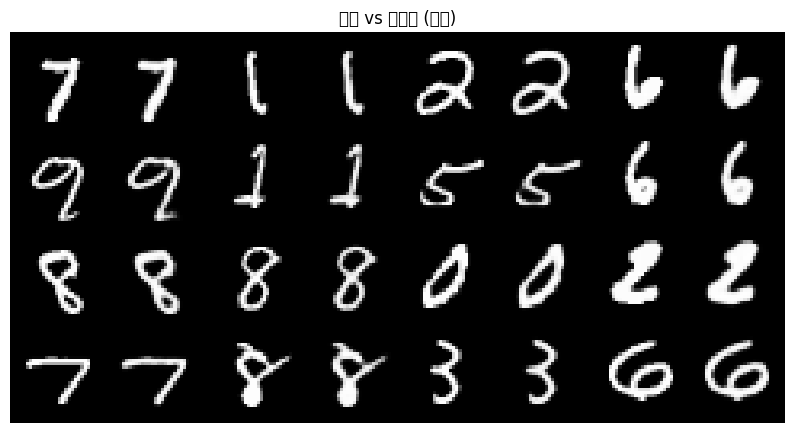

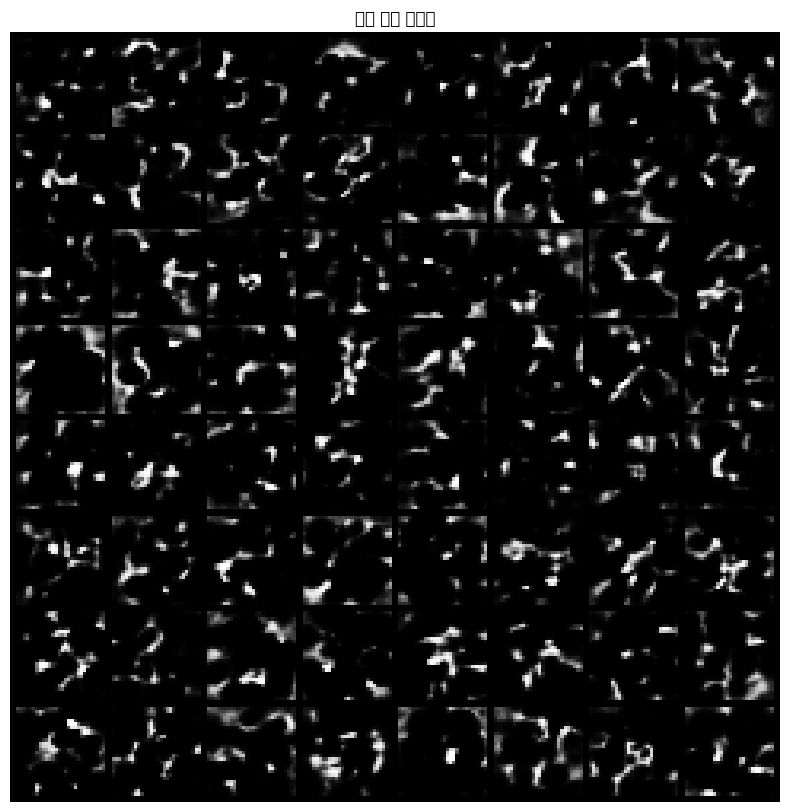

Saved: ./samples_ae/epoch_020.png
\n학습 완료!


In [10]:
# 학습 시작
global_step = 0
loss_history = []

model.train()
for epoch in range(1, CFG["epochs"] + 1):
    epoch_loss = 0.0

    for batch_idx, (images, _) in enumerate(dloader):
        images = images.to(device)

        # Forward pass
        recon = model(images)
        loss = criterion(recon, images)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        # 학습 진행 상황 출력
        if global_step % 100 == 0:
            print(f"[{epoch}/{CFG['epochs']}] step {global_step} | loss={loss.item():.4f}")

        global_step += 1

    # Epoch 평균 loss
    avg_loss = epoch_loss / len(dloader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch} 완료 | 평균 Loss: {avg_loss:.4f}")

    # Epoch마다 재구성 결과 시각화
    if epoch % 5 == 0 or epoch == 1:
        show_reconstruction(num_images=16)

        # 샘플 이미지 저장
        with torch.no_grad():
            samples = generate_random_samples(num_samples=64)
        save_path = os.path.join(CFG["out_dir"], f"epoch_{epoch:03d}.png")
        utils.save_image(samples, save_path, nrow=8, normalize=False)
        print(f"Saved: {save_path}")

print("\\n학습 완료!")


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


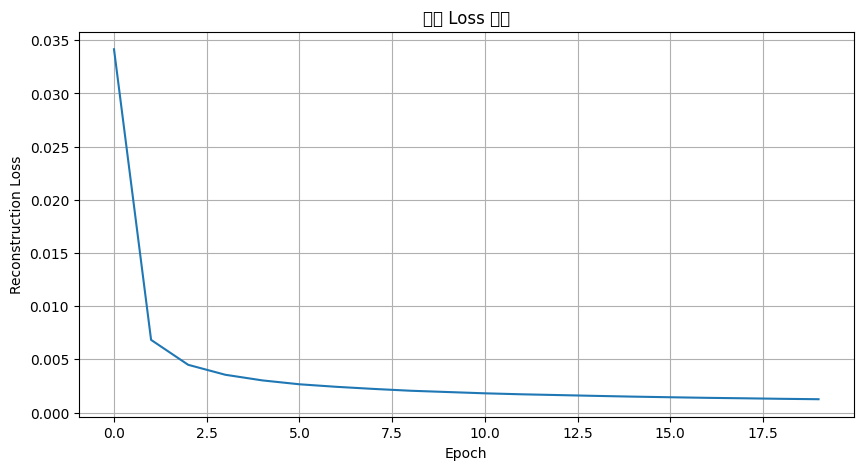

In [11]:
# Loss 그래프 시각화
plt.figure(figsize=(10, 5))
plt.plot(loss_history)
plt.title('학습 Loss 변화')
plt.xlabel('Epoch')
plt.ylabel('Reconstruction Loss')
plt.grid(True)
plt.show()


# 재구성 결과 확인


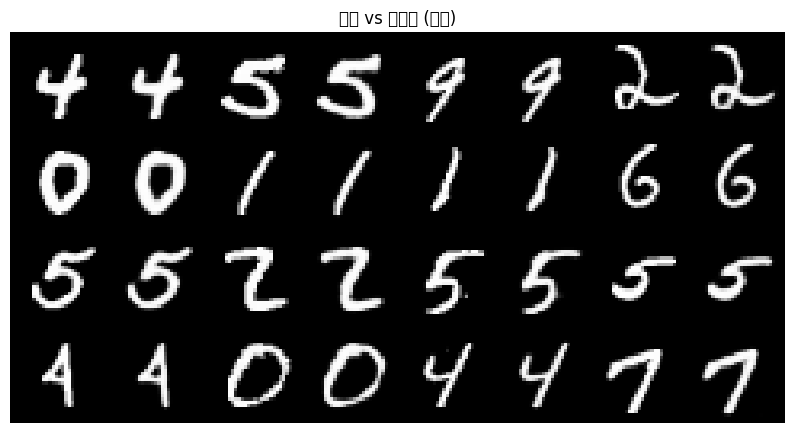

In [12]:
# 테스트 이미지로 재구성 확인
show_reconstruction(num_images=16)


# 잠재공간에서 새로운 이미지 생성


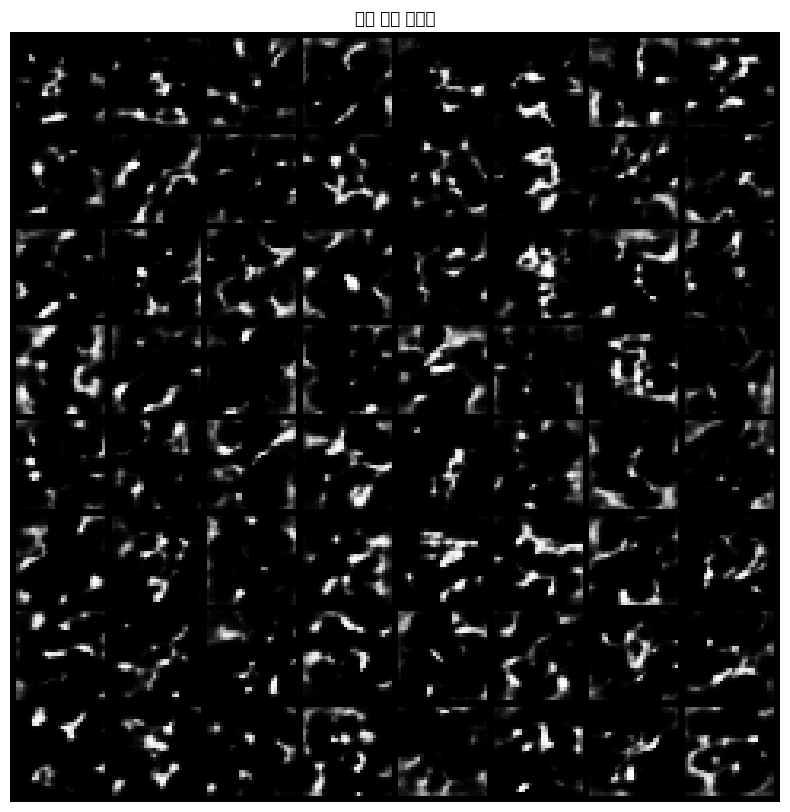

tensor([[[[7.4525e-04, 5.7567e-05, 5.3025e-05,  ..., 1.8050e-04,
           3.7136e-04, 2.2655e-03],
          [1.9254e-04, 2.2237e-05, 3.4985e-05,  ..., 1.5871e-04,
           3.0839e-04, 1.6144e-03],
          [1.2136e-04, 8.5043e-05, 4.5189e-05,  ..., 4.7601e-04,
           6.1524e-04, 1.1138e-03],
          ...,
          [6.0458e-05, 5.4713e-07, 2.0719e-08,  ..., 1.7996e-01,
           2.0168e-01, 2.1895e-01],
          [1.2743e-05, 3.0511e-07, 5.3531e-08,  ..., 3.9815e-02,
           4.8595e-02, 5.7754e-02],
          [3.6910e-06, 1.8444e-07, 1.1023e-08,  ..., 7.7086e-03,
           1.1714e-02, 1.5302e-02]]],


        [[[1.8951e-03, 5.5879e-04, 1.3738e-04,  ..., 7.2601e-02,
           6.9415e-02, 8.7371e-02],
          [9.6315e-05, 1.1802e-05, 8.3611e-06,  ..., 8.9400e-03,
           1.4965e-02, 4.4668e-02],
          [1.0871e-05, 1.4733e-06, 3.3882e-07,  ..., 8.8105e-05,
           3.5830e-04, 1.1174e-03],
          ...,
          [1.1356e-02, 9.6457e-03, 1.4072e-02,  ..., 9.16

In [13]:
# 랜덤하게 새로운 숫자 이미지 생성
generate_random_samples(num_samples=64)


# 잠재공간 보간 (Interpolation)


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


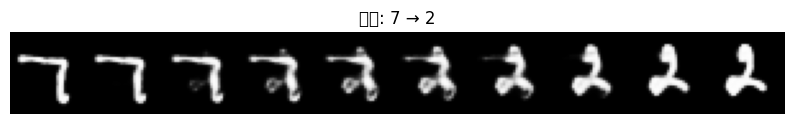

In [14]:
@torch.no_grad()
def interpolate_latent_space(num_steps=10):
    """두 개의 랜덤 잠재벡터 사이를 보간하여 변화 과정 시각화"""
    model.eval()

    # 두 개의 랜덤 이미지 선택
    idx1, idx2 = torch.randint(0, len(dataset), (2,))
    img1, label1 = dataset[idx1]
    img2, label2 = dataset[idx2]

    # 잠재벡터 추출
    z1 = model.encode(img1.unsqueeze(0).to(device))
    z2 = model.encode(img2.unsqueeze(0).to(device))

    # 보간
    interpolated = []
    for alpha in np.linspace(0, 1, num_steps):
        z_interp = (1 - alpha) * z1 + alpha * z2
        img_interp = model.decode(z_interp)
        interpolated.append(img_interp.squeeze(0).cpu())

    interpolated = torch.stack(interpolated)
    show_tensor_images(interpolated, nrow=num_steps,
                      title=f"보간: {label1} → {label2}")
    model.train()

# 보간 시각화 실행
interpolate_latent_space(num_steps=10)


In [15]:
# 원하는 숫자 이미지 생성

생성할 숫자 선택 (0-9): 7


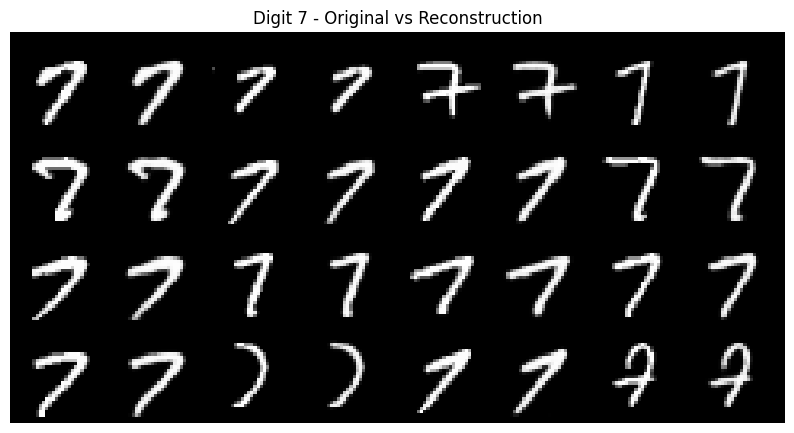

In [16]:
@torch.no_grad()
def generate_digit_samples(digit, num_samples=16):
    """특정 숫자의 이미지를 찾아 재구성하여 보여주기"""
    model.eval()

    # 해당 숫자의 이미지 찾기
    digit_images = []
    for img, label in dataset:
        if label == digit:
            digit_images.append(img)
        if len(digit_images) >= num_samples:
            break

    if len(digit_images) == 0:
        print(f"숫자 {digit}의 이미지를 찾을 수 없습니다.")
        return

    # 텐서로 변환
    digit_images = torch.stack(digit_images).to(device)

    # 재구성
    recon_images = model(digit_images)

    # 원본과 재구성을 나란히 비교
    comparison = torch.zeros(len(digit_images) * 2, 1, CFG["image_size"], CFG["image_size"])
    for i in range(len(digit_images)):
        comparison[i*2] = digit_images[i].cpu()
        comparison[i*2 + 1] = recon_images[i].cpu()

    show_tensor_images(comparison, nrow=8, title=f"Digit {digit} - Original vs Reconstruction")

    model.train()
    return recon_images

# 사용자 입력으로 원하는 숫자 생성
num = input("생성할 숫자 선택 (0-9): ")
try:
    digit = int(num)
    if 0 <= digit <= 9:
        generate_digit_samples(digit, num_samples=16)
    else:
        print("0-9 사이의 숫자를 입력해주세요.")
except ValueError:
    print("올바른 숫자를 입력해주세요.")


# Variational AutoEncoder (VAE) 구현


# VAE Hyperparameter 설정


In [17]:
VAE_CFG = {
    "epochs": 5,
    "batch_size": 128,
    "lr": 1e-3,
    "latent_dim": 128,    # 잠재공간 차원
    "image_size": 28,     # MNIST 원본 크기
    "beta": 1.0,          # KL Divergence 가중치 (β-VAE)
    "num_workers": 2,
    "seed": 42,
    "out_dir": "./samples_vae",
    "data_root": "./data",
}

print("VAE Hyperparameters:")
for key, value in VAE_CFG.items():
    print(f"  {key}: {value}")

# 결과 저장 경로 생성
Path(VAE_CFG["out_dir"]).mkdir(parents=True, exist_ok=True)


VAE Hyperparameters:
  epochs: 20
  batch_size: 128
  lr: 0.001
  latent_dim: 128
  image_size: 28
  beta: 1.0
  num_workers: 2
  seed: 42
  out_dir: ./samples_vae
  data_root: ./data


## VAE 모델 정의

VAE는 일반 AE와 달리:
- 잠재공간을 가우시안 분포로 정규화
- μ(평균)과 σ(표준편차)를 학습
- Reparameterization trick 사용
- 랜덤 샘플링이 가능!


In [18]:
# VAE Encoder: 이미지 -> μ, log_σ²
class VAE_Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),  # 14x14
            nn.ReLU(True),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), # 7x7
            nn.ReLU(True),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), # 4x4
            nn.ReLU(True),
        )
        # μ와 log_σ²를 출력
        self.fc_mu = nn.Linear(128 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(128 * 4 * 4, latent_dim)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar


In [19]:
# VAE Decoder (일반 AE와 동일)
class VAE_Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 128 * 4 * 4)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),  # 8x8
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),   # 16x16
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 1, 4, stride=2, padding=3),    # 28x28
            nn.Sigmoid(),
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(x.size(0), 128, 4, 4)
        x = self.deconv(x)
        return x


In [20]:
# VAE 전체 모델
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = VAE_Encoder(latent_dim)
        self.decoder = VAE_Decoder(latent_dim)

    def reparameterize(self, mu, logvar):
        """Reparameterization trick: z = μ + σ * ε"""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar

    def encode(self, x):
        mu, logvar = self.encoder(x)
        return mu, logvar

    def decode(self, z):
        return self.decoder(z)

# VAE 모델 생성
vae = VAE(VAE_CFG["latent_dim"]).to(device)
print(f"VAE 파라미터 수: {sum(p.numel() for p in vae.parameters()):,}")


VAE 파라미터 수: 1,045,857


## VAE Loss 함수 정의


In [21]:
def vae_loss_function(recon_x, x, mu, logvar, beta=1.0):
    """
    VAE Loss = Reconstruction Loss + β * KL Divergence
    beta: KL Divergence 가중치 (β-VAE)
    """
    # Reconstruction loss (MSE)
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')

    # KL Divergence: -0.5 * sum(1 + log(σ²) - μ² - σ²)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + beta * kl_loss, recon_loss, kl_loss

# Optimizer
vae_optimizer = optim.Adam(vae.parameters(), lr=VAE_CFG["lr"])


## VAE 학습


[1/20] step 0 | loss=200.3891 recon=200.3365 kl=0.0526
[1/20] step 100 | loss=54.7412 recon=52.8265 kl=1.9147
[1/20] step 200 | loss=49.9942 recon=45.9661 kl=4.0281
[1/20] step 300 | loss=42.8605 recon=36.1160 kl=6.7446
[1/20] step 400 | loss=38.7408 recon=29.6385 kl=9.1023
Epoch 1 완료 | 평균 Loss: 51.3865 (Recon: 45.8570, KL: 5.5295)


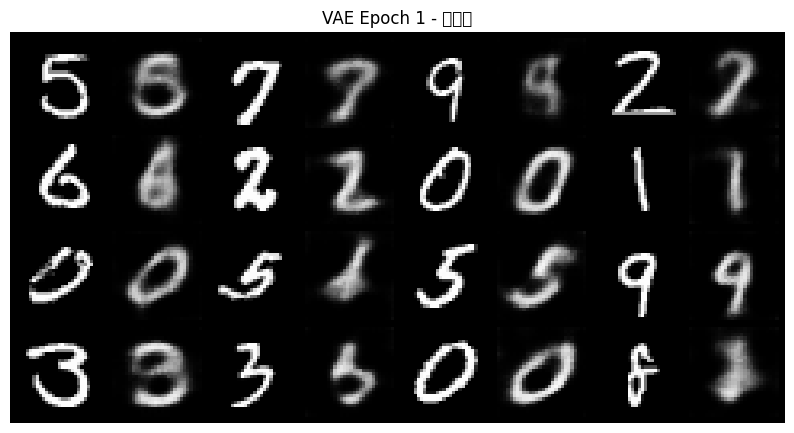

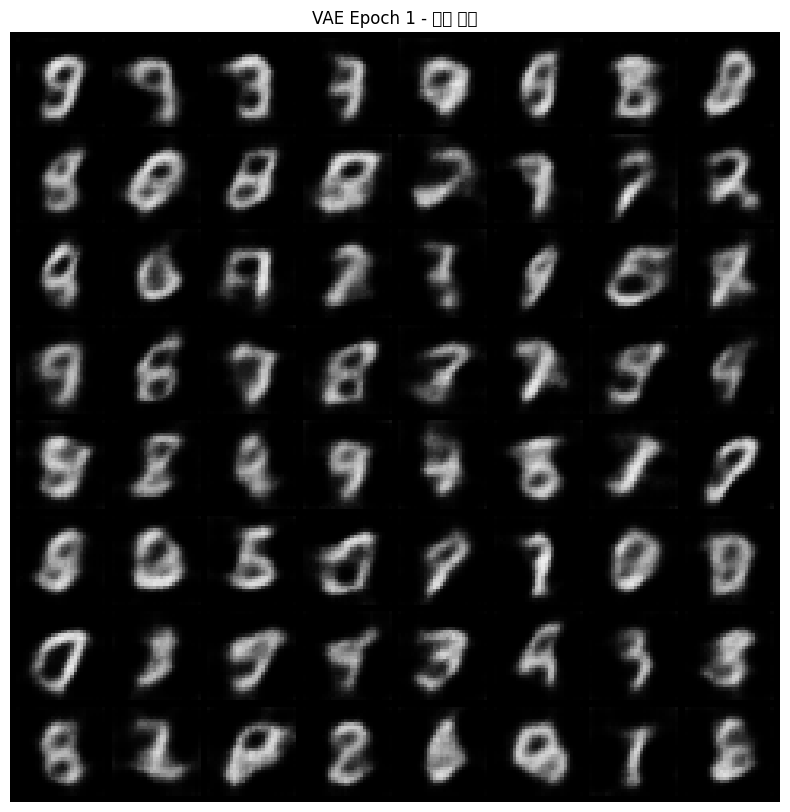

Saved: ./samples_ae/vae_epoch_001.png
[2/20] step 500 | loss=39.1369 recon=29.1826 kl=9.9542
[2/20] step 600 | loss=34.8749 recon=25.0120 kl=9.8629
[2/20] step 700 | loss=35.3790 recon=24.6724 kl=10.7066
[2/20] step 800 | loss=33.7449 recon=23.0784 kl=10.6666
[2/20] step 900 | loss=34.2387 recon=23.9091 kl=10.3295
Epoch 2 완료 | 평균 Loss: 35.0651 (Recon: 24.5989, KL: 10.4662)
[3/20] step 1000 | loss=33.1694 recon=22.0866 kl=11.0828
[3/20] step 1100 | loss=32.0400 recon=21.2504 kl=10.7896
[3/20] step 1200 | loss=32.0306 recon=20.7266 kl=11.3040
[3/20] step 1300 | loss=31.9714 recon=20.8286 kl=11.1428
[3/20] step 1400 | loss=30.3123 recon=19.0791 kl=11.2332
Epoch 3 완료 | 평균 Loss: 32.2689 (Recon: 21.0128, KL: 11.2562)
[4/20] step 1500 | loss=32.0563 recon=20.1615 kl=11.8948
[4/20] step 1600 | loss=31.2667 recon=19.8542 kl=11.4125
[4/20] step 1700 | loss=31.0988 recon=19.4569 kl=11.6419
[4/20] step 1800 | loss=30.0342 recon=18.2654 kl=11.7688
Epoch 4 완료 | 평균 Loss: 31.1250 (Recon: 19.4535, KL: 

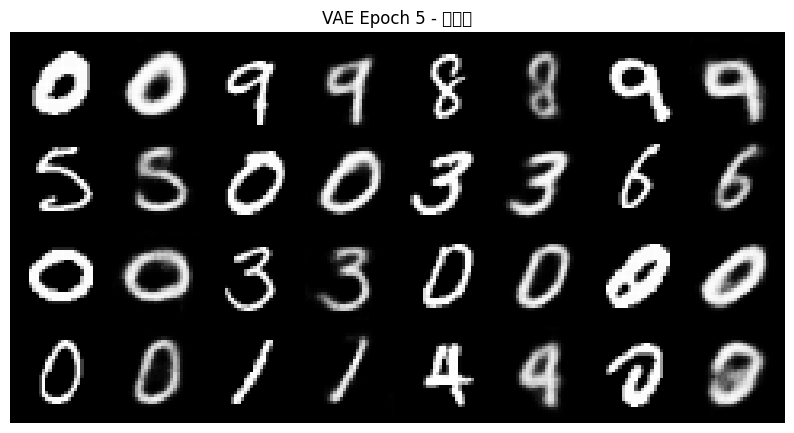

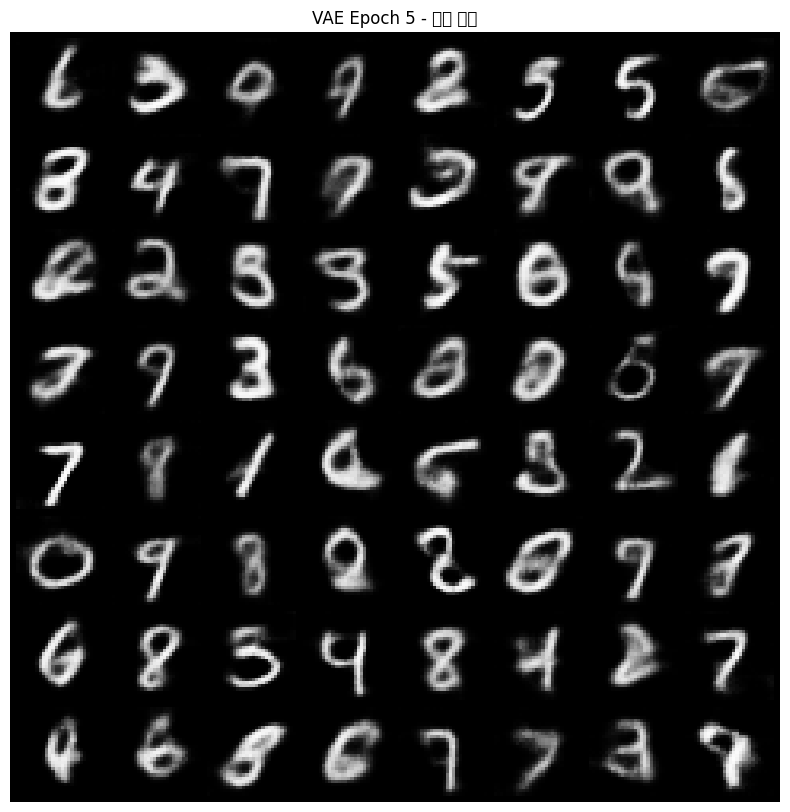

Saved: ./samples_ae/vae_epoch_005.png
[6/20] step 2400 | loss=31.3787 recon=19.3818 kl=11.9969
[6/20] step 2500 | loss=29.7037 recon=17.6827 kl=12.0210
[6/20] step 2600 | loss=30.0765 recon=18.2973 kl=11.7792
[6/20] step 2700 | loss=30.6946 recon=19.1666 kl=11.5280
[6/20] step 2800 | loss=29.1954 recon=17.1364 kl=12.0590
Epoch 6 완료 | 평균 Loss: 29.9357 (Recon: 18.0400, KL: 11.8957)
[7/20] step 2900 | loss=29.3597 recon=17.4729 kl=11.8868
[7/20] step 3000 | loss=30.2462 recon=17.5746 kl=12.6716
[7/20] step 3100 | loss=29.0876 recon=16.9694 kl=12.1182
[7/20] step 3200 | loss=29.2251 recon=17.7566 kl=11.4685
Epoch 7 완료 | 평균 Loss: 29.6359 (Recon: 17.6788, KL: 11.9571)
[8/20] step 3300 | loss=29.2434 recon=17.3597 kl=11.8837
[8/20] step 3400 | loss=28.0278 recon=16.3675 kl=11.6603
[8/20] step 3500 | loss=29.4133 recon=17.8633 kl=11.5499
[8/20] step 3600 | loss=30.1397 recon=18.0167 kl=12.1230
[8/20] step 3700 | loss=27.9261 recon=16.5160 kl=11.4101
Epoch 8 완료 | 평균 Loss: 29.4023 (Recon: 17.420

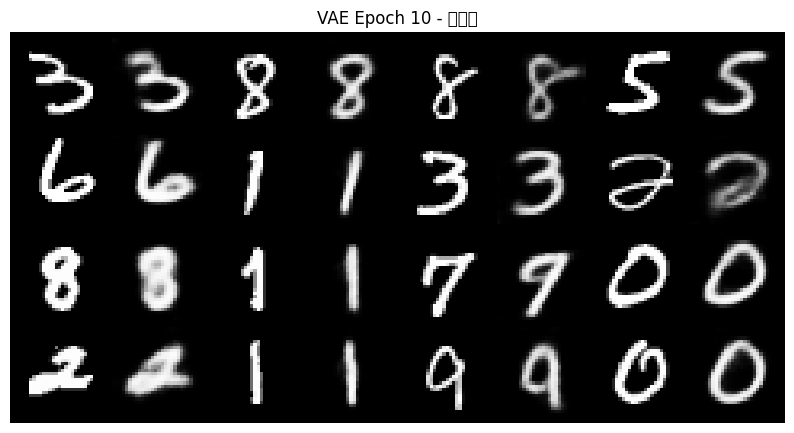

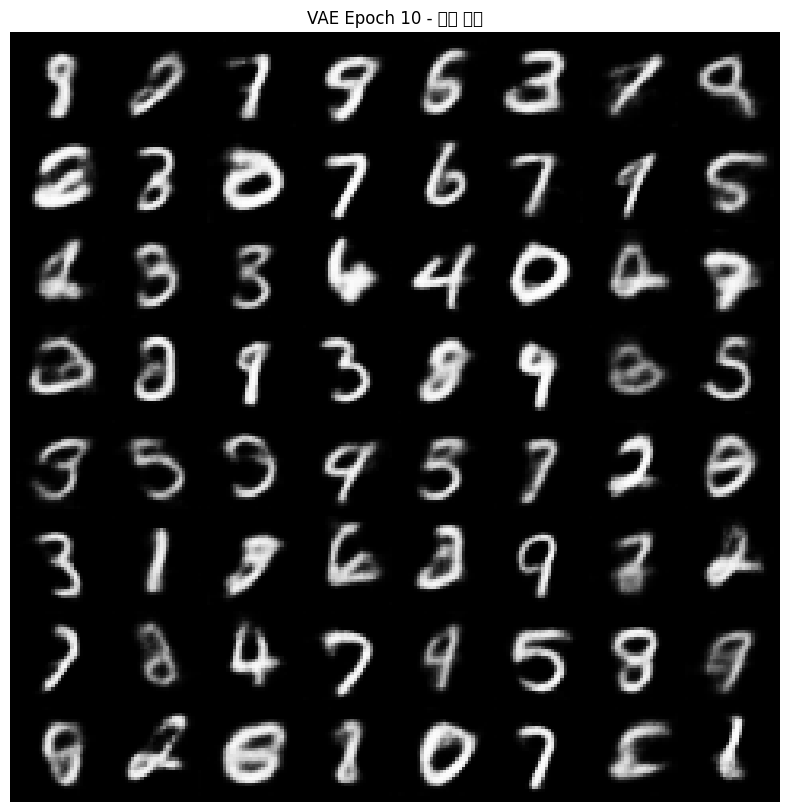

Saved: ./samples_ae/vae_epoch_010.png
[11/20] step 4700 | loss=27.8678 recon=16.1817 kl=11.6861
[11/20] step 4800 | loss=28.4256 recon=16.6445 kl=11.7811
[11/20] step 4900 | loss=28.9051 recon=17.1511 kl=11.7541
[11/20] step 5000 | loss=28.7740 recon=16.7987 kl=11.9753
[11/20] step 5100 | loss=30.8608 recon=18.8844 kl=11.9764
Epoch 11 완료 | 평균 Loss: 28.8535 (Recon: 16.7974, KL: 12.0561)
[12/20] step 5200 | loss=29.3637 recon=17.2505 kl=12.1132
[12/20] step 5300 | loss=29.5223 recon=17.1620 kl=12.3603
[12/20] step 5400 | loss=28.3324 recon=16.1232 kl=12.2092
[12/20] step 5500 | loss=28.1245 recon=15.9275 kl=12.1969
[12/20] step 5600 | loss=28.6208 recon=16.4650 kl=12.1558
Epoch 12 완료 | 평균 Loss: 28.7334 (Recon: 16.6419, KL: 12.0915)
[13/20] step 5700 | loss=29.3259 recon=17.4016 kl=11.9243
[13/20] step 5800 | loss=28.3717 recon=15.9040 kl=12.4677
[13/20] step 5900 | loss=29.0719 recon=17.3316 kl=11.7403
[13/20] step 6000 | loss=27.8335 recon=15.8420 kl=11.9915
Epoch 13 완료 | 평균 Loss: 28.60

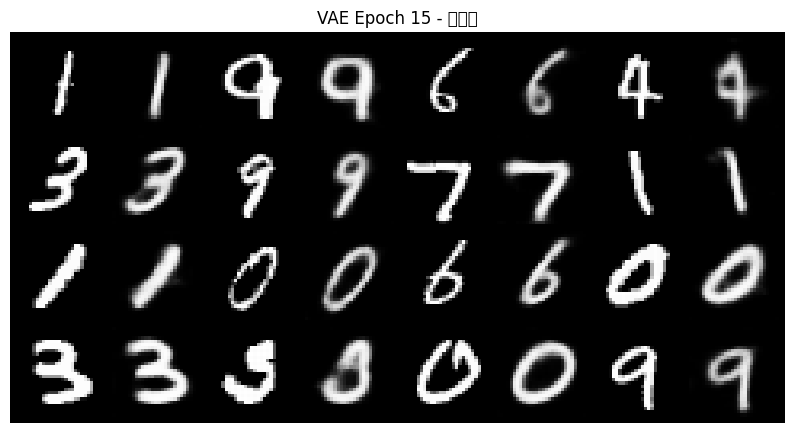

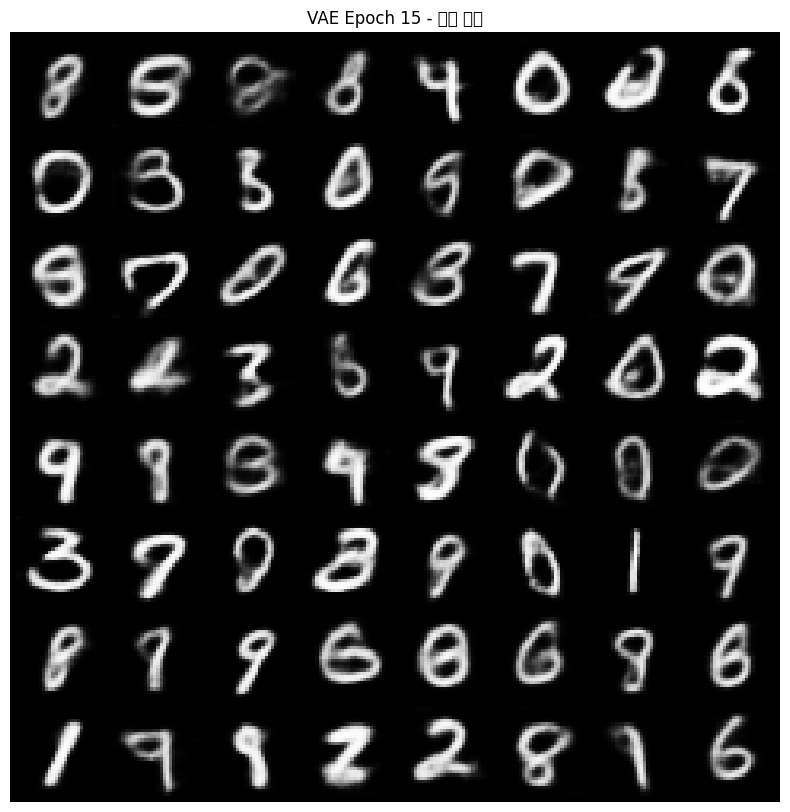

Saved: ./samples_ae/vae_epoch_015.png
[16/20] step 7100 | loss=28.1133 recon=16.0163 kl=12.0971
[16/20] step 7200 | loss=29.2731 recon=17.2630 kl=12.0102
[16/20] step 7300 | loss=28.4111 recon=16.0444 kl=12.3667
[16/20] step 7400 | loss=27.6001 recon=15.8562 kl=11.7439
Epoch 16 완료 | 평균 Loss: 28.2840 (Recon: 16.1809, KL: 12.1031)
[17/20] step 7500 | loss=27.2852 recon=15.3772 kl=11.9080
[17/20] step 7600 | loss=27.8427 recon=15.7691 kl=12.0736
[17/20] step 7700 | loss=27.7828 recon=15.4878 kl=12.2950


In [ ]:
# VAE 학습 시작
vae_global_step = 0
vae_loss_history = []
vae_recon_history = []
vae_kl_history = []

vae.train()
for epoch in range(1, CFG["epochs"] + 1):
    epoch_loss = 0.0
    epoch_recon = 0.0
    epoch_kl = 0.0

    for batch_idx, (images, _) in enumerate(dloader):
        images = images.to(device)

        # Forward pass
        recon, mu, logvar = vae(images)
        loss, recon_loss, kl_loss = vae_loss_function(recon, images, mu, logvar)

        # Backward pass
        vae_optimizer.zero_grad()
        loss.backward()
        vae_optimizer.step()

        epoch_loss += loss.item()
        epoch_recon += recon_loss.item()
        epoch_kl += kl_loss.item()

        # 학습 진행 상황 출력
        if vae_global_step % 100 == 0:
            print(f"[{epoch}/{CFG['epochs']}] step {vae_global_step} | "
                  f"loss={loss.item()/images.size(0):.4f} "
                  f"recon={recon_loss.item()/images.size(0):.4f} "
                  f"kl={kl_loss.item()/images.size(0):.4f}")

        vae_global_step += 1

    # Epoch 평균 loss
    avg_loss = epoch_loss / len(dloader) / CFG["batch_size"]
    avg_recon = epoch_recon / len(dloader) / CFG["batch_size"]
    avg_kl = epoch_kl / len(dloader) / CFG["batch_size"]

    vae_loss_history.append(avg_loss)
    vae_recon_history.append(avg_recon)
    vae_kl_history.append(avg_kl)

    print(f"Epoch {epoch} 완료 | 평균 Loss: {avg_loss:.4f} "
          f"(Recon: {avg_recon:.4f}, KL: {avg_kl:.4f})")

    # Epoch마다 샘플 시각화 및 저장
    if epoch % 5 == 0 or epoch == 1:
        with torch.no_grad():
            vae.eval()
            # 재구성 확인
            indices = torch.randint(0, len(dataset), (16,))
            test_images = torch.stack([dataset[i][0] for i in indices]).to(device)
            test_recon, _, _ = vae(test_images)

            comparison = torch.zeros(32, 1, CFG["image_size"], CFG["image_size"])
            for i in range(16):
                comparison[i*2] = test_images[i].cpu()
                comparison[i*2 + 1] = test_recon[i].cpu()

            show_tensor_images(comparison, nrow=8, title=f"VAE Epoch {epoch} - 재구성")

            # 랜덤 샘플링 (VAE는 가능!)
            z = torch.randn(64, CFG["latent_dim"], device=device)
            samples = vae.decode(z)
            show_tensor_images(samples.cpu(), nrow=8, title=f"VAE Epoch {epoch} - 랜덤 생성")

            # 저장
            save_path = os.path.join(CFG["out_dir"], f"vae_epoch_{epoch:03d}.png")
            utils.save_image(samples.cpu(), save_path, nrow=8, normalize=False)
            print(f"Saved: {save_path}")
            vae.train()

print("\\n VAE 학습 완료!")


## VAE Loss 그래프 시각화


In [ ]:
# VAE Loss 그래프
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(vae_loss_history)
axes[0].set_title('VAE Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True)

axes[1].plot(vae_recon_history)
axes[1].set_title('VAE Reconstruction Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].grid(True)

axes[2].plot(vae_kl_history)
axes[2].set_title('VAE KL Divergence')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].grid(True)

plt.tight_layout()
plt.show()


## VAE 랜덤 샘플링 테스트


In [ ]:
# VAE는 랜덤 샘플링이 가능!
@torch.no_grad()
def vae_generate_random(num_samples=64):
    vae.eval()
    z = torch.randn(num_samples, VAE_CFG["latent_dim"], device=device)
    samples = vae.decode(z)
    show_tensor_images(samples.cpu(), nrow=8, title="VAE 랜덤 생성 이미지")
    vae.train()
    return samples

vae_generate_random(num_samples=64)


## VAE 잠재공간 보간


In [ ]:
@torch.no_grad()
def vae_interpolate_latent_space(num_steps=10):
    """VAE 잠재공간 보간"""
    vae.eval()

    # 두 개의 랜덤 이미지 선택
    idx1, idx2 = torch.randint(0, len(dataset), (2,))
    img1, label1 = dataset[idx1]
    img2, label2 = dataset[idx2]

    # 잠재벡터 추출 (μ 사용)
    mu1, _ = vae.encode(img1.unsqueeze(0).to(device))
    mu2, _ = vae.encode(img2.unsqueeze(0).to(device))

    # 보간
    interpolated = []
    for alpha in np.linspace(0, 1, num_steps):
        z_interp = (1 - alpha) * mu1 + alpha * mu2
        img_interp = vae.decode(z_interp)
        interpolated.append(img_interp.squeeze(0).cpu())

    interpolated = torch.stack(interpolated)
    show_tensor_images(interpolated, nrow=num_steps,
                      title=f"VAE 보간: {label1} → {label2}")
    vae.train()

# 보간 시각화 실행
vae_interpolate_latent_space(num_steps=10)


## VAE 모델 저장


In [ ]:
# VAE 모델 저장
vae_model_path = os.path.join(VAE_CFG["out_dir"], "vae_mnist.pth")
torch.save({
    'model_state_dict': vae.state_dict(),
    'optimizer_state_dict': vae_optimizer.state_dict(),
    'config': VAE_CFG,
}, vae_model_path)
print(f"VAE 모델 저장 완료: {vae_model_path}")


## VAE로 원하는 숫자의 이미지 생성


생성할 숫자 선택 (0-9): 8

[방법 1] 학습된 잠재 분포에서 새로운 이미지 생성:


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49707 (\N{HANGUL SYLLABLE SUS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51104 (\N{HANGUL SYLLABLE JAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lo

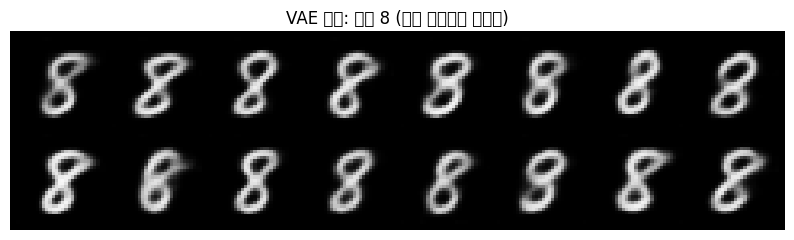


[방법 2] 실제 이미지 재구성:


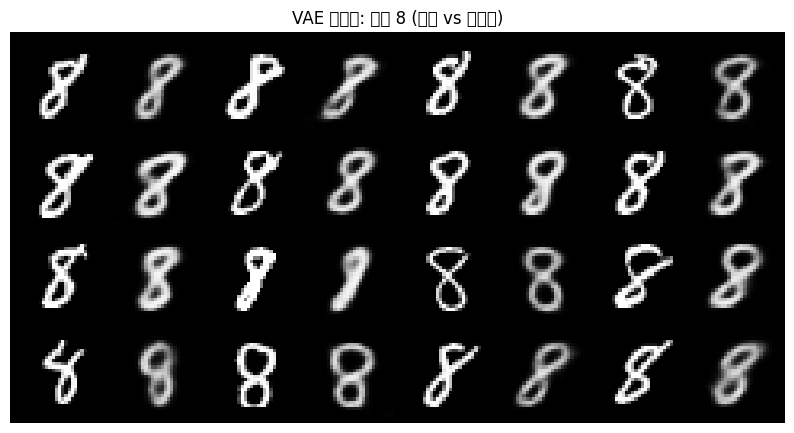

In [27]:
@torch.no_grad()
def vae_generate_digit_samples(digit, num_samples=16, use_learned_distribution=True):
    """
    VAE로 특정 숫자 이미지 생성

    방법 1 (use_learned_distribution=True):
        해당 숫자의 학습된 잠재 분포(μ, σ)에서 샘플링
    방법 2 (use_learned_distribution=False):
        해당 숫자의 실제 이미지를 재구성
    """
    vae.eval()

    # 해당 숫자의 이미지 찾기
    digit_images = []
    for img, label in dataset:
        if label == digit:
            digit_images.append(img)
        if len(digit_images) >= 50:  # 충분한 샘플 수집
            break

    if len(digit_images) == 0:
        print(f"숫자 {digit}의 이미지를 찾을 수 없습니다.")
        return

    digit_images_tensor = torch.stack(digit_images).to(device)

    if use_learned_distribution:
        # 방법 1: 학습된 분포에서 새로운 샘플 생성
        # 해당 숫자의 평균 잠재 분포 계산
        mu_list, logvar_list = [], []
        for img in digit_images_tensor:
            mu, logvar = vae.encode(img.unsqueeze(0))
            mu_list.append(mu)
            logvar_list.append(logvar)

        # 평균 μ와 σ 계산
        mean_mu = torch.mean(torch.cat(mu_list, dim=0), dim=0, keepdim=True)
        mean_logvar = torch.mean(torch.cat(logvar_list, dim=0), dim=0, keepdim=True)

        # 학습된 분포 주변에서 샘플링
        samples = []
        for _ in range(num_samples):
            # reparameterization trick
            std = torch.exp(0.5 * mean_logvar)
            eps = torch.randn_like(std)
            z = mean_mu + eps * std
            generated = vae.decode(z)
            samples.append(generated.squeeze(0).cpu())

        samples = torch.stack(samples)
        show_tensor_images(samples, nrow=8,
                          title=f"VAE 생성: 숫자 {digit} (잠재 분포에서 샘플링)")
    else:
        # 방법 2: 실제 이미지 재구성
        selected = digit_images_tensor[:num_samples]
        recon, _, _ = vae(selected)

        # 원본과 재구성 비교
        comparison = torch.zeros(len(selected) * 2, 1, VAE_CFG["image_size"], VAE_CFG["image_size"])
        for i in range(len(selected)):
            comparison[i*2] = selected[i].cpu()
            comparison[i*2 + 1] = recon[i].cpu()

        show_tensor_images(comparison, nrow=8,
                          title=f"VAE 재구성: 숫자 {digit} (원본 vs 재구성)")
        samples = recon.cpu()

    vae.train()
    return samples

# 사용자 입력으로 원하는 숫자 생성
num = input("생성할 숫자 선택 (0-9): ")
try:
    digit = int(num)
    if 0 <= digit <= 9:
        print("\n[방법 1] 학습된 잠재 분포에서 새로운 이미지 생성:")
        vae_generate_digit_samples(digit, num_samples=16, use_learned_distribution=True)

        print("\n[방법 2] 실제 이미지 재구성:")
        vae_generate_digit_samples(digit, num_samples=16, use_learned_distribution=False)
    else:
        print("0-9 사이의 숫자를 입력해주세요.")
except ValueError:
    print("올바른 숫자를 입력해주세요.")
